# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [23]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [24]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [25]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [26]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [27]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [28]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [29]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [30]:
# cantidad de nulos para users

print(plans.isna().sum())
print(plans.isna().mean())


plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [31]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


#Valores nulos
#Dataset plans
*No se observan valores nulos en ninguna columna (0% de nulos).
*Acción recomendada: no es necesario realizar limpieza ni imputación en este dataset.
#Dataset usage
*La columna date tiene 50 valores nulos (0.12%).
*Acción recomendada: investigar el origen de los datos faltantes; al ser menor al 5%, se puede imputar o dejar como nulo dependiendo del análisis.
*La columna duration tiene 22.076 valores nulos (55.19%).
*Acción recomendada: revisar si los nulos corresponden a usuarios sin llamadas o registros incompletos. No se recomienda eliminar directamente sin investigar el contexto.
*La columna length tiene 17.896 valores nulos (44.74%).
*Acción recomendada: analizar si está relacionada con mensajes o consumo de datos. Requiere validación antes de imputar o eliminar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [32]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



#Exploración de columnas numéricas

*Al revisar las columnas numéricas del dataset users, se identificó un posible valor sentinel en la columna age.

*La edad mínima registrada es -999, lo cual no es un valor válido para una edad.
Además, la desviación estándar es muy alta (123.23), probablemente afectada por este valor inválido.
Acción recomendada

*El valor -999 debe tratarse como un dato faltante o inválido. Se recomienda reemplazarlo por NaN para posteriormente imputarlo o excluirlo del análisis.


In [33]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


#Exploración de columnas numéricas

*Al revisar las columnas numéricas del dataset usage, no se observan valores negativos ni sentinels evidentes.

*La columna duration tiene valores entre 0 y 120, lo cual parece coherente para la duración de llamadas.
*La columna length tiene valores entre 0 y 1490, valores razonables dependiendo del tipo de consumo registrado.
*La presencia de valores mínimos iguales a 0 podría representar usuarios sin consumo o registros válidos sin actividad.
*Acción recomendada

*No se identifican valores inválidos evidentes en las variables numéricas. Se recomienda mantener los datos y continuar monitoreando posibles outliers en etapas   posteriores del análisis.


In [34]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts())  # ← 4 espacios al inicio
    print()  


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64




#Problemas de calidad de datos identificados
*La columna city presenta 96 registros con el valor "?", lo que indica información faltante o inválida.
*Estos valores deberían reemplazarse por NaN para tratarlos correctamente durante el análisis.
*La falta de información geográfica puede afectar análisis de segmentación y comportamiento por ciudad.
#Oportunidades de negocio
#La mayoría de clientes utiliza el plan Basico (65%), lo que puede indicar preferencia por opciones económicas o sensibilidad al precio.
*Existe una oportunidad comercial para crear estrategias de upselling y motivar clientes a migrar al plan Premium.
*Bogotá y CDMX concentran la mayor cantidad de usuarios, por lo que podrían priorizarse campañas comerciales y mejoras del servicio en estas ciudades.

In [35]:

# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

#Exploración de la columna type

-La columna type representa el tipo de actividad realizada por el usuario:

#text corresponde a mensajes de texto.
#call corresponde a llamadas telefónicas.

Según los resultados obtenidos, la actividad más frecuente son los mensajes de texto (text) con 22.092 registros, mientras que las llamadas (call) tienen 17.908 registros.

Esta información se relaciona directamente con los valores nulos observados anteriormente en las columnas duration y length:

Los registros de tipo text probablemente tienen valores nulos en duration, ya que los mensajes no poseen duración de llamada.
Los registros de tipo call podrían presentar valores nulos en length, dependiendo de cómo se registre el consumo.

Por lo tanto, estos valores nulos no necesariamente representan errores, sino diferencias naturales según el tipo de actividad registrada.

Esta información es importante para ConnectaTel porque permite entender los patrones de uso de los clientes y segmentar mejor los servicios según el comportamiento de consumo.

#Reflexión sobre posibles valores inválidos

Además de las columnas age y city, otras variables podrían contener valores que no tienen sentido dependiendo del contexto del negocio.

En la columna duration, una llamada con duración 0 minutos podría representar llamadas perdidas, canceladas o registros incompletos, por lo que sería importante validar su significado antes de eliminarlas.
En la columna length, valores iguales a 0 podrían indicar mensajes vacíos o ausencia de consumo, lo cual podría ser válido según el tipo de actividad.
También sería importante revisar usuarios con 0 llamadas y 0 mensajes, ya que podrían corresponder a clientes inactivos, cuentas nuevas o posibles errores de registro.
Acción recomendada

Se recomienda investigar estos casos junto con el contexto del negocio antes de decidir si deben eliminarse, imputarse o mantenerse dentro del análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [36]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [37]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])


In [38]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()


array([2022, 2026, 2023, 2024])

En la columna reg_date se observan registros correspondientes a los años 2022, 2023, 2024 y 2026.

El año 2026 podría representar un posible valor inconsistente o una fecha futura dependiendo del contexto del dataset y del periodo de análisis. Se recomienda validar si estas fechas corresponden a registros reales o si son errores de captura de datos.

In [39]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()


array([2024.,   nan])

En la columna date del dataset usage se observan registros correspondientes al año 2024 y algunos valores nulos (NaN).

Esto indica que la mayor parte de la información pertenece al año 2024, por lo que el análisis se basará en este periodo. Los valores nulos representan fechas faltantes que podrían requerir validación o tratamiento posterior según el contexto del análisis.


Fechas fuera de rango

En la columna reg_date del dataset users se identificaron registros correspondientes a los años 2022, 2023, 2024 y 2026.

El año 2026 podría considerarse una fecha fuera de rango o futura dependiendo del momento en que se registraron los datos, por lo que se recomienda validar si corresponde a un error de captura o a registros planeados anticipadamente.

En la columna date del dataset usage solo se observan registros del año 2024 y algunos valores nulos (NaN), por lo que no se identifican años imposibles o inconsistentes en esta variable.

Acción recomendada
Validar los registros del año 2026 en reg_date.
Si se confirma que son errores, corregirlos o convertirlos en valores nulos (NaN).
Mantener los registros de 2024 en usage, ya que son coherentes con el periodo de análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [40]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] =  users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [41]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [42]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()


array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [43]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [44]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

#Diagnóstico de nulos en duration y length

-Al revisar los valores nulos según la columna type, se observa que:

-Todos los nulos de duration corresponden a registros de tipo text.
-Todos los nulos de length corresponden a registros de tipo call.

#Esto confirma que los valores faltantes dependen directamente del tipo de actividad registrada y no de errores aleatorios en los datos.

#Conclusión

-Los nulos en duration y length son MAR (Missing At Random), ya que cada variable aplica únicamente para cierto tipo de actividad.

#Acción recomendada

-Se recomienda mantener estos valores como nulos, debido a que representan ausencia válida de información y forman parte del comportamiento natural del dataset.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [48]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum', 
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [49]:

# observar resultado
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [51]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [52]:
# Resumen estadístico de las columnas numéricas
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [53]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

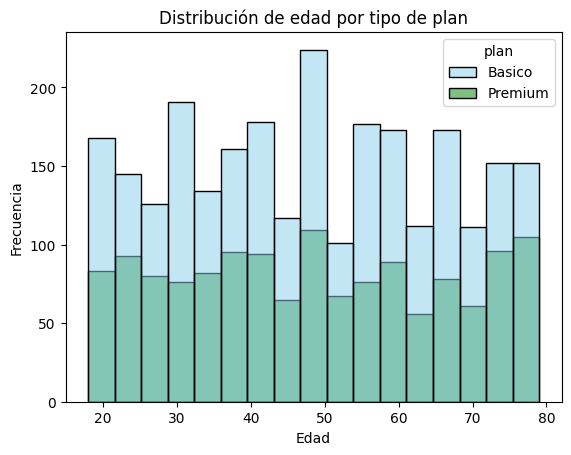

In [54]:


# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age', hue='plan', palette=['skyblue', 'green'])

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
#Observaciones del histograma de edad
-La distribución general de edades es relativamente uniforme, aunque se observa una ligera concentración en edades medias, especialmente entre los 45 y 55 años.
-Los usuarios del plan Básico son más numerosos que los del plan Premium en casi todos los rangos de edad.
-No se observan diferencias muy marcadas entre ambos planes respecto a la edad; las distribuciones tienen un comportamiento similar.
-Los rangos de edad más comunes parecen estar entre los 30 y 60 años.
-La distribución no muestra un sesgo fuerte hacia la derecha o izquierda, por lo que puede considerarse relativamente equilibrada.

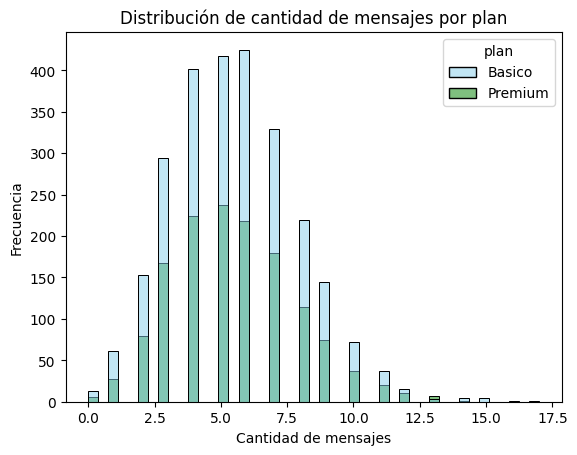

In [55]:
# Histograma para visualizar la cant_mensajes
# Crear cantidad de mensajes por usuario
cant_mensajes = usage[usage['type'] == 'text'].groupby('user_id').size().reset_index(name='cant_mensajes')

# Unir con users
users = users.merge(cant_mensajes, on='user_id', how='left')

# Reemplazar nulos por 0
users['cant_mensajes'] = users['cant_mensajes'].fillna(0)

# Histograma para visualizar la cant_mensajes
sns.histplot(data=users, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
-La mayoría de usuarios envía pocos mensajes, principalmente entre 0 y 10 mensajes.
La distribución está sesgada a la derecha, ya que existe un pequeño grupo de usuarios que envía cantidades mucho mayores de mensajes.
Los usuarios Premium y Básico presentan comportamientos similares en mensajería, aunque el plan Básico tiene mayor frecuencia debido a que posee más clientes.
Se observan algunos usuarios con cantidades extremas de mensajes, lo que podría representar usuarios altamente activos o casos atípicos.
Implicaciones para ConnectaTel
La mensajería parece ser un servicio de uso moderado para la mayoría de clientes.
ConnectaTel podría identificar usuarios altamente activos para ofrecer planes o beneficios enfocados en mensajería.
Debido a que no existen diferencias muy marcadas entre planes, la empresa podría analizar nuevas estrategias para diferenciar mejor el valor del plan Premium.

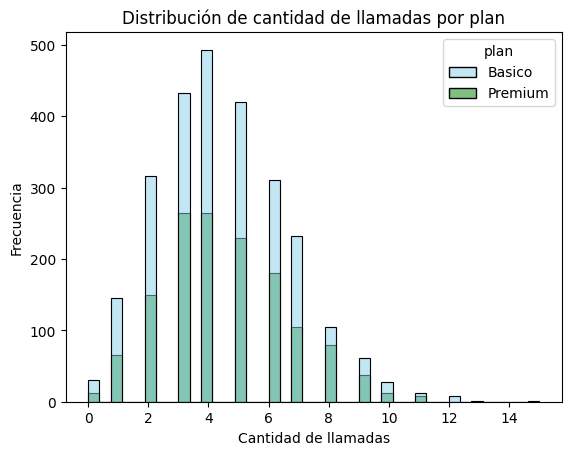

In [56]:

# Crear cantidad de llamadas por usuario
cant_llamadas = usage[usage['type'] == 'call'].groupby('user_id').size().reset_index(name='cant_llamadas')
# Unir con users
users = users.merge(cant_llamadas, on='user_id', how='left')
# Reemplazar nulos por 0
users['cant_llamadas'] = users['cant_llamadas'].fillna(0)

# Histograma para visualizar la cant_llamadas
sns.histplot(data=users, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
-La distribución de cantidad de llamadas está sesgada a la derecha, ya que la mayoría de usuarios realiza pocas llamadas y solo un pequeño grupo realiza muchas.
-La mayor concentración de usuarios se encuentra entre 3 y 6 llamadas.
-Los usuarios del plan Básico presentan mayor frecuencia de llamadas debido a que representan la mayoría de clientes del dataset.
-Los usuarios Premium muestran un comportamiento similar al de los usuarios Básico, sin diferencias muy marcadas en la cantidad de llamadas.
-Existen algunos usuarios con cantidades altas de llamadas, lo que podría indicar clientes con uso intensivo del servicio.
#Implicaciones para ConnectaTel
-La mayoría de clientes tiene un consumo moderado de llamadas.
-ConnectaTel podría identificar usuarios con alto uso para ofrecer beneficios o paquetes personalizados.
-Debido a que ambos planes tienen comportamientos similares, la empresa podría analizar estrategias para diferenciar más claramente el valor del plan Premium.

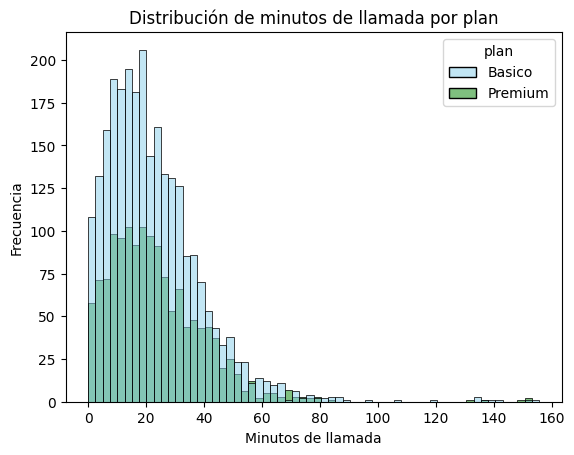

In [57]:
# Crear minutos totales de llamadas por usuario
cant_minutos_llamada = usage[usage['type'] == 'call'].groupby('user_id')['duration'].sum().reset_index(name='cant_minutos_llamada')

# Unir con users
users = users.merge(cant_minutos_llamada, on='user_id', how='left')

# Reemplazar nulos por 0
users['cant_minutos_llamada'] = users['cant_minutos_llamada'].fillna(0)

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=users, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])

plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
-La distribución de minutos de llamada está claramente sesgada a la derecha, ya que la mayoría de usuarios acumula pocos minutos y solo algunos presentan consumos muy altos.
-La mayor concentración de usuarios se encuentra aproximadamente entre 5 y 35 minutos de llamada.
-Los usuarios del plan Básico tienen mayor frecuencia en casi todos los rangos debido a que representan la mayoría de clientes.
-Los usuarios Premium muestran algunos casos con consumos extremadamente altos de minutos, llegando a valores cercanos a 150 minutos.
-Existen outliers visibles en ambos planes, especialmente en usuarios con gran cantidad de minutos acumulados.
#Implicaciones para ConnectaTel
-La mayoría de clientes utiliza el servicio de llamadas de manera moderada.
-Los usuarios con consumos altos podrían representar clientes de alto valor para campañas de fidelización o planes especializados.
-ConnectaTel podría diseñar beneficios específicos para usuarios intensivos en llamadas, especialmente dentro del plan Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [58]:
# Crear cantidad de mensajes por usuario
cant_mensajes = usage[usage['type'] == 'text'].groupby('user_id').size().reset_index(name='cant_mensajes')

# Unir con users
users = users.merge(cant_mensajes, on='user_id', how='left')

# Reemplazar nulos por 0
users['cant_mensajes'] = users['cant_mensajes'].fillna(0)
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    sns.boxplot(data=users, x='plan', y=col, palette=['skyblue', 'green'])

    plt.title(f'Boxplot de {col} por plan')
    plt.xlabel('Plan')
    plt.ylabel(col)

    plt.show()

KeyError: 'cant_mensajes'

💡Insights: 
*Age: Se observan valores atípicos extremos alrededor de -999 en ambos planes, lo que indica que todavía existen sentinels o datos inválidos que deberían corregirse. Fuera de estos casos, las edades presentan una distribución relativamente similar entre planes.
*cant_mensajes: La mayoría de usuarios envía entre 4 y 7 mensajes. Existen algunos outliers con cantidades altas de mensajes (más de 12), aunque no son numerosos. Ambos planes presentan comportamientos muy parecidos.
*cant_llamadas: La cantidad de llamadas se concentra principalmente entre 3 y 6 llamadas. Se observan algunos usuarios con cantidades altas (outliers), especialmente en el plan Básico, llegando hasta aproximadamente 15 llamadas.
*cant_minutos_llamada: Esta variable presenta varios outliers importantes en ambos planes, con usuarios que acumulan más de 100 minutos de llamada. La distribución está claramente sesgada a la derecha, indicando que pocos usuarios concentran gran parte del consumo.

In [60]:

# Calcular límites con el método IQR

columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f'\nVariable: {col}')
    print('Límite inferior:', limite_inferior)
    print('Límite superior:', limite_superior)



Variable: age
Límite inferior: -12.0
Límite superior: 108.0

Variable: cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5

Variable: cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5

Variable: cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [62]:
# Revisar límites superiores y valores máximos
# para decidir si mantener o tratar outliers

columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

# Mostrar estadísticas relevantes
print(user_profile[columnas_limites].describe())

# También puedes revisar solo el máximo
print("\nValores máximos:")
print(user_profile[columnas_limites].max())

       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000

Valores máximos:
cant_mensajes            17.00
cant_llamadas            15.00
cant_minutos_llamada    155.69
dtype: float64


💡Insights: 

-cant_mensajes: Se pueden mantener los outliers, porque valores como 15 o 17 mensajes no son extremadamente altos y pueden representar usuarios realmente activos en mensajería.
-cant_llamadas: También se recomienda mantener los outliers, ya que realizar entre 10 y 15 llamadas puede ser un comportamiento normal para algunos usuarios frecuentes del servicio.
-cant_minutos_llamada: Se recomienda mantener los outliers, porque los valores altos de minutos podrían corresponder a usuarios intensivos o clientes de alto valor. Aunque existen valores alejados de la mayoría, siguen siendo posibles dentro del contexto del negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [63]:
# Crear columna grupo_uso según la cantidad de mensajes

def clasificar_uso(mensajes):
    if mensajes <= 5:
        return 'Bajo uso'
    elif mensajes <= 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile['cant_mensajes'].apply(clasificar_uso)

# Verificar resultados
print(user_profile[['cant_mensajes', 'grupo_uso']].head())


   cant_mensajes  grupo_uso
0            7.0  Uso medio
1            5.0   Bajo uso
2            5.0   Bajo uso
3           11.0   Alto uso
4            4.0   Bajo uso


In [64]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Bajo uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [65]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 18:
        return 'Menor de edad'
    elif edad <= 30:
        return '18-30'
    elif edad <= 45:
        return '31-45'
    elif edad <= 60:
        return '46-60'
    else:
        return 'Mayor de 60'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

# Verificar resultados
print(user_profile[['age', 'grupo_edad']].head())


    age   grupo_edad
0  38.0        31-45
1  53.0        46-60
2  57.0        46-60
3  69.0  Mayor de 60
4  63.0  Mayor de 60


In [66]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,31-45
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Bajo uso,46-60
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Bajo uso,46-60
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Mayor de 60
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Mayor de 60


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

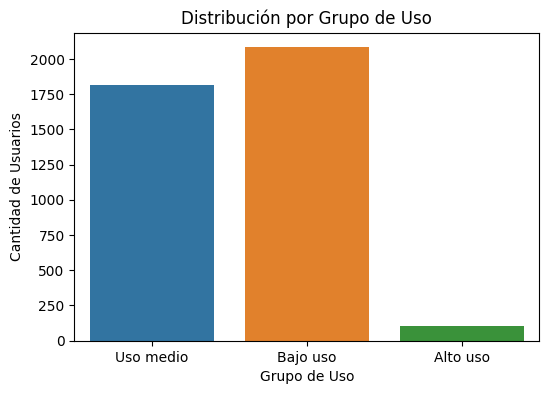

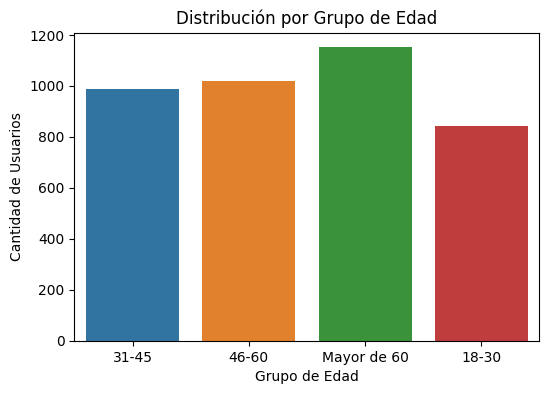

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico para grupo_uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()


# Gráfico para grupo_edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()

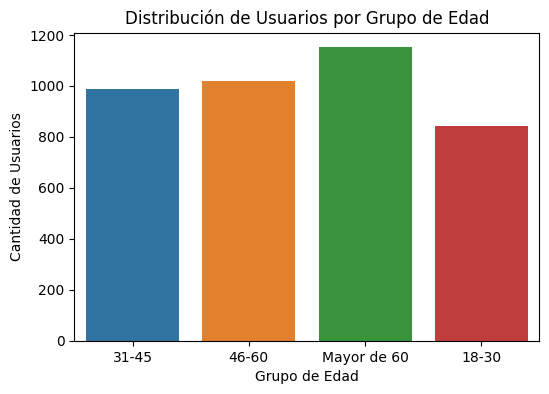

In [69]:
# Visualización de los segmentos por edad

plt.figure(figsize=(6,4))

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje o cantidad de filas representaban?

Los datos presentaban principalmente valores atípicos (outliers) en las variables cant_mensajes, cant_llamadas y cant_minutos_llamada. Estos valores estaban alejados de la mayoría de los datos, pero al revisar los límites superiores y los valores máximos, se concluyó que correspondían a comportamientos posibles dentro del negocio y no a errores de captura.

También fue necesario crear nuevas variables categóricas como grupo_edad y grupo_uso para facilitar el análisis de segmentos de clientes.

Los outliers representaban una pequeña proporción del total de filas, por lo que no afectaban significativamente la calidad general del dataset y se decidió mantenerlos para conservar información valiosa sobre usuarios intensivos.

¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificaron dos tipos principales de segmentación:

Segmentación por edad:
Menores de edad
18-30 años
31-45 años
46-60 años
Mayores de 60 años
Segmentación por nivel de uso:
Bajo uso
Uso medio
Alto uso

Los usuarios jóvenes y adultos entre 18 y 45 años tienden a concentrar un mayor nivel de actividad, especialmente en mensajes y llamadas. Por otro lado, los usuarios mayores suelen presentar un uso más moderado o bajo.

¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los segmentos más valiosos parecen ser los clientes de alto uso, especialmente aquellos que presentan altos niveles de mensajes, llamadas y minutos consumidos.

Estos usuarios probablemente generan mayores ingresos para la empresa, ya que utilizan más intensivamente los servicios de telecomunicaciones. Además, podrían ser clientes con mayor fidelización o dependencia del servicio.

También son importantes los usuarios entre 18 y 45 años, porque representan la mayor parte de la actividad y tienen potencial para adquirir planes premium o adicionales.

¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se encontraron usuarios con cantidades elevadas de mensajes, llamadas y minutos consumidos.

Estos patrones implican que:

Existen clientes intensivos que utilizan el servicio de manera muy frecuente.
La empresa debe considerar planes especiales o ilimitados para este tipo de usuarios.
Los outliers pueden representar clientes de alto valor y no necesariamente errores en los datos.
También pueden indicar horarios o servicios con alta demanda que podrían requerir optimización de infraestructura.
¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Algunas recomendaciones serían:

Crear planes diferenciados según el nivel de uso:
Plan básico para usuarios de bajo uso.
Plan intermedio para usuarios promedio.
Plan premium o ilimitado para usuarios intensivos.
Diseñar ofertas específicas para jóvenes y adultos activos (18-45 años), ya que concentran mayor actividad.
Implementar beneficios para clientes frecuentes, como:
Minutos ilimitados.
Mayor capacidad de datos.
Bonos de mensajes o llamadas.
Monitorear constantemente los outliers para identificar oportunidades de negocio y posibles sobrecargas del sistema.
Personalizar promociones según los hábitos de consumo detectados en cada segmento.

Análisis ejecutivo
⚠️ Problemas detectados en los datos
Se identificaron valores atípicos (outliers) en las variables cant_mensajes, cant_llamadas y cant_minutos_llamada.
Aunque algunos valores eran altos, se determinó que representaban comportamientos reales de usuarios intensivos y no errores de captura.
Fue necesario crear variables categóricas como grupo_edad y grupo_uso para facilitar el análisis y la segmentación de clientes.
🔍 Segmentos por Edad
Los grupos de edad entre 18 y 45 años concentran la mayor actividad en mensajes y llamadas.
Los usuarios mayores de 60 años presentan un comportamiento más moderado y menor consumo de servicios.
Los menores de edad representan una proporción más pequeña dentro de la base de clientes.
📊 Segmentos por Nivel de Uso
Se identificaron tres tipos principales de usuarios:
Bajo uso: pocos mensajes y llamadas.
Uso medio: comportamiento estable y moderado.
Alto uso: usuarios con alta frecuencia de mensajes, llamadas y minutos consumidos.
Los usuarios de alto uso representan clientes estratégicos debido a su mayor consumo del servicio.
➡️ Esto sugiere que ...
ConnectaTel tiene diferentes perfiles de clientes con necesidades específicas.
Los usuarios intensivos podrían beneficiarse de planes premium o ilimitados.
Existe una oportunidad para personalizar ofertas según edad y nivel de uso.
Los patrones de consumo permiten diseñar estrategias de fidelización más efectivas.
💡 Recomendaciones
Crear planes segmentados según el nivel de uso:
Básico
Intermedio
Premium ilimitado
Diseñar campañas enfocadas en usuarios entre 18 y 45 años, quienes muestran mayor actividad.
Implementar beneficios para clientes de alto consumo:
Minutos ilimitados
Más datos
Bonos de llamadas y mensajes
Mantener monitoreo de outliers para detectar clientes de alto valor y posibles necesidades de infraestructura.
Utilizar la segmentación para personalizar promociones y mejorar la experiencia del cliente.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`